This notebook estimates the intensity distribution coming out of a vortex waveplate.

# Imports

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import astropy.modeling

# Functions

In [2]:
def Vortex(l, x, y):
    ''' Performs the "phase screw" transformation.
        Inputs:
        - l: charge of the vortex waveplate
        - x, y: Cartesian coordinates
        Outputs:
        - Intensity distribution in object plane?
    '''
    theta = np.arctan2(y, x)
    return np.exp(1.j * l * theta)

# Generate pupil mask (beam)

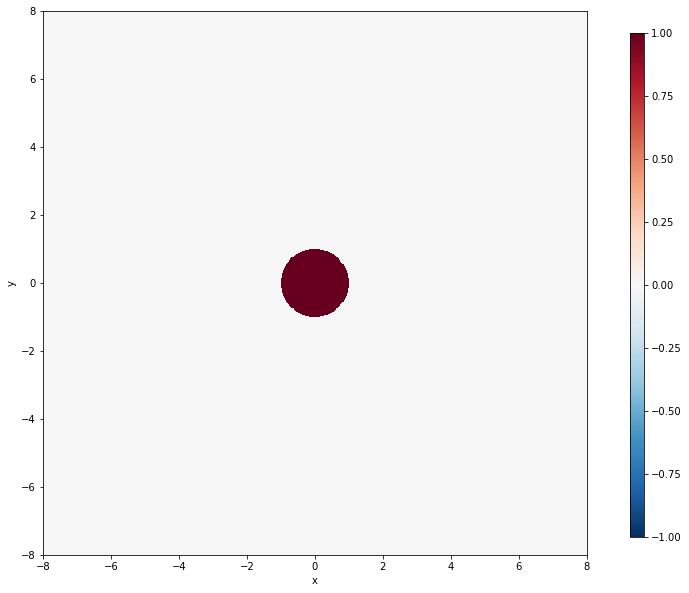

In [16]:
# Generate beam pixels
power = 9
samples = 2**power
FOV = 8
x_samples = np.linspace(-FOV, FOV, samples)
x, y = np.meshgrid(x_samples, x_samples)
r = np.sqrt(x**2. + y**2.)
P = np.ones_like(x)

# Generate circular mask
mask = r <= 1.0

# Apply mask to make a pupil of size unity
P_mask = np.copy(P)
P_mask[~mask] = 0

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color = 'gray', alpha = 1.)
ax0 = ax.pcolormesh(x, y, P_mask, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xlabel('x')
ax.set_ylabel('y')
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

# Define vortex phase field centered on pupil

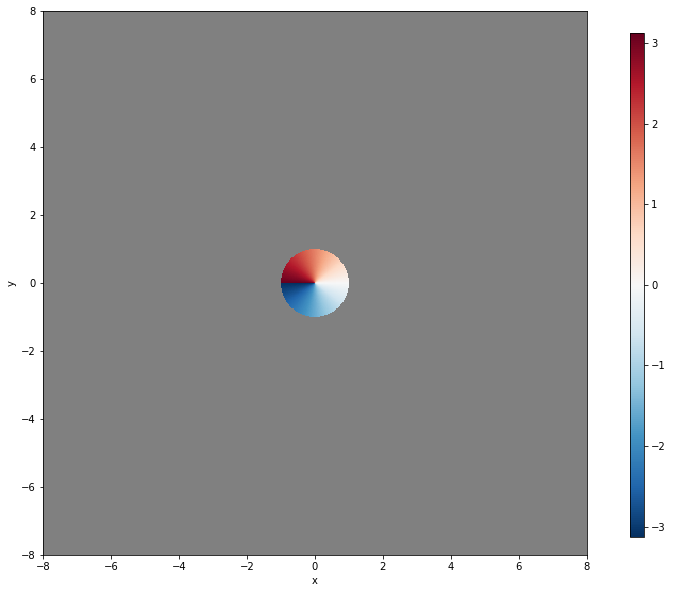

In [17]:
# Perform vortex transformation
l = 1
V = Vortex(l, x, y)
V_phase = np.angle(V)

# Phase transformation of vortex with circular aperture
mask = r <= 1.0
V_phase_mask = np.copy(V_phase)
V_phase_mask[~mask] = np.NaN

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color = 'gray', alpha = 1.)
ax0 = ax.pcolormesh(x, y, V_phase_mask, cmap='RdBu_r')
ax.set_xlabel('x')
ax.set_ylabel('y')
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

# Generate image plane

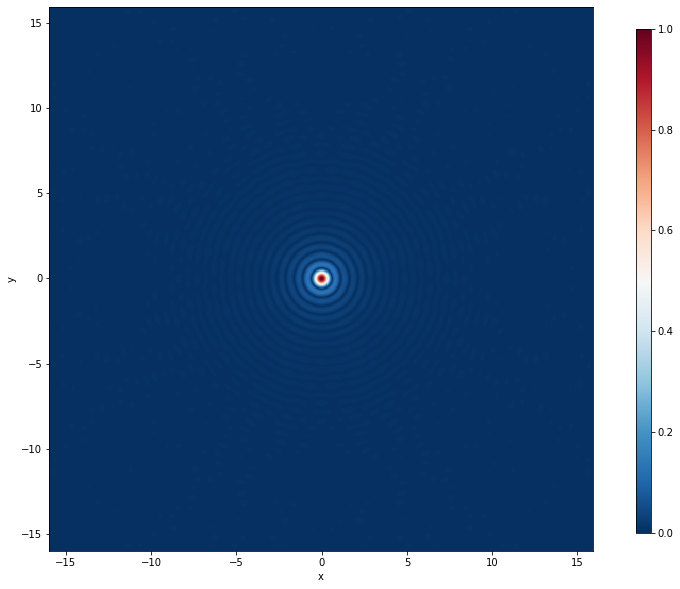

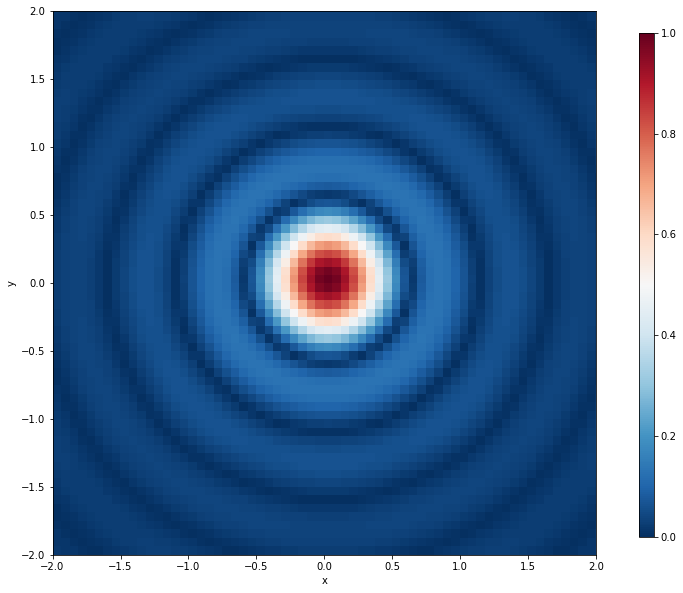

In [20]:
# Image the aperture without vortex
P_transform_noVortex = np.copy(P_mask)

# Fourier Transform for image formation
dx = np.mean(x_samples[1:]-x_samples[:-1])
dy = np.copy(dx)
X = np.fft.fftshift(np.fft.fftfreq(len(x), d=dx))
Y = np.copy(X)
I_noVortex = np.fft.fft2(np.fft.ifftshift(P_transform_noVortex)) # shift zero frequency component to center of spectrum
I_noVortex = np.fft.fftshift(I_noVortex) # shift back
I_noVortex = np.absolute(I_noVortex)
I_noVortex = I_noVortex/np.max(I_noVortex)

# Full image
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax.pcolormesh(X, Y, I_noVortex, cmap='RdBu_r')#, norm=matplotlib.colors.LogNorm(vmin=I_noVortex.min(), 
#                                                                                     vmax=I_noVortex.max()))
ax.set_xlabel('x')
ax.set_ylabel('y')
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

# Focus on Airy disk at center
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax.pcolormesh(X, Y, I_noVortex, cmap='RdBu_r')#, norm=matplotlib.colors.LogNorm(vmin=I_noVortex.min(), 
#                                                                                     vmax=I_noVortex.max()))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

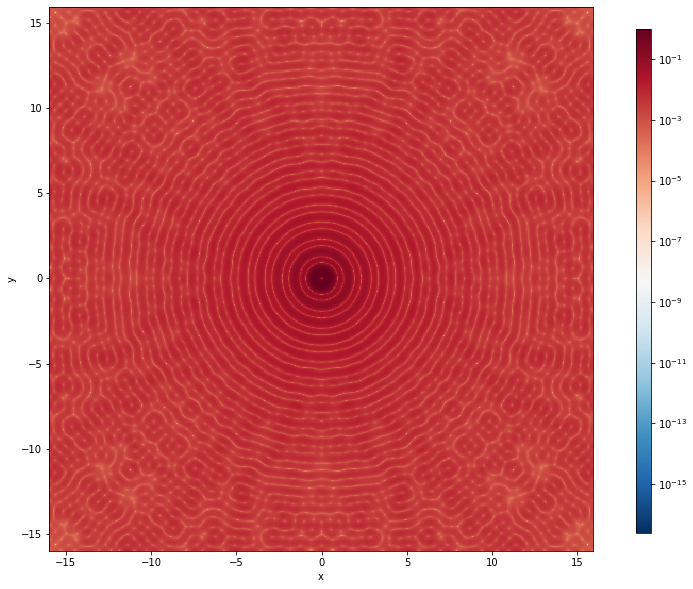

In [21]:
# Apply vortex transformation
P_transform = V * P_mask

P_transform = P_transform/np.max(P_transform)

# Fourier Transform for image formation
dx = np.mean(x_samples[1:]-x_samples[:-1])
X = np.fft.fftshift(np.fft.fftfreq(len(x), d=dx))
Y = np.copy(X)
I = np.fft.fft2(np.fft.ifftshift(P_transform)) # shift zero frequency component to center of spectrum
I = np.fft.fftshift(I) # shift back
I_intensity = np.absolute(I)
I_intensity = I_intensity/np.max(I_intensity)
I_phase = np.angle(I)

# Full image
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax.pcolormesh(X, Y, I_intensity, cmap='RdBu_r', 
                    norm=matplotlib.colors.LogNorm(vmin=I_intensity.min(), vmax=I_intensity.max()))
ax.set_xlabel('x')
ax.set_ylabel('y')
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

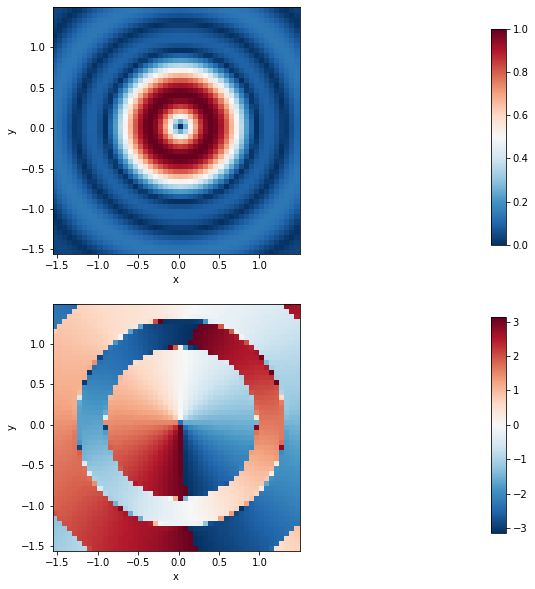

In [26]:
# Focus on Airy disk at center
center = int(np.ceil(samples/2))
window = int(samples/20)
low, up = center-window, center+window

fig, ax = plt.subplots(2, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax[0].pcolormesh(X[low:up], Y[low:up], I_intensity[low:up,low:up], cmap='RdBu_r')#, 
#                       norm=matplotlib.colors.LogNorm(vmin=I_intensity[low:up,low:up].min(), 
#                                                      vmax=I_intensity[low:up,low:up].max()))
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
# ax[0].set_xlim(-4, 4)
# ax[0].set_ylim(-4, 4)
cax0 = fig.add_axes([0.95, 0.55, 0.02, 0.3]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax0, orientation = 'vertical') #'ax0' tells it which plot to base the colors on

ax1 = ax[1].pcolormesh(X[low:up], Y[low:up], I_phase[low:up,low:up], cmap='RdBu_r')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
# ax[1].set_xlim(-4, 4)
# ax[1].set_ylim(-4, 4)
cax1 = fig.add_axes([0.95, 0.15, 0.02, 0.3]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax1, cax1, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

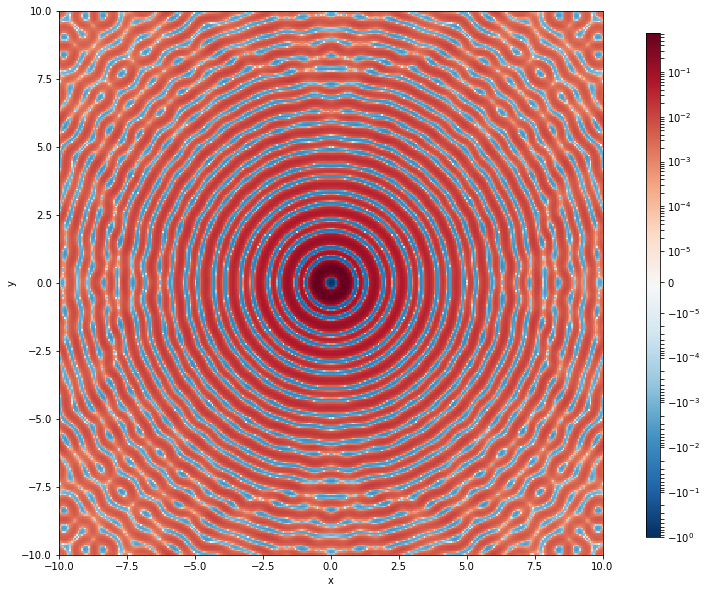

In [39]:
I_diff = I_intensity-I_noVortex

fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax.pcolormesh(X, Y, I_diff, cmap='RdBu_r', norm=matplotlib.colors.SymLogNorm(linthresh=1e-5, 
                                                                                   vmin=I_diff.min(), vmax=I_diff.max()))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

# Couple into fiber centered on beam

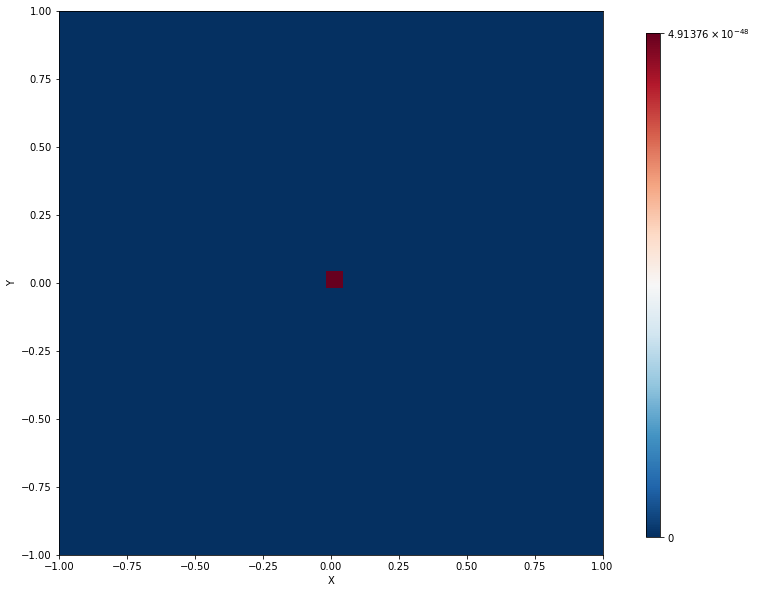

In [38]:
# Generate single-mode fiber mode profile
fiber_MFD = 4.5 * 10.**(-6)
beam_diameter = 3. * 10.**(-3)
fiber_width = fiber_MFD/beam_diameter
center = np.array([0, 0])
width = np.array([[fiber_width, 0],[0, fiber_width]])
GaussianKernel = astropy.modeling.functional_models.Gaussian2D(amplitude=1, x_mean=0, y_mean=0, 
                                                               x_stddev=fiber_width, y_stddev=fiber_width)
fiber_profile = GaussianKernel(x, y)


fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax.pcolormesh(x, y, fiber_profile, cmap='RdBu_r', 
                    norm=matplotlib.colors.SymLogNorm(linthresh=1e-7, 
                                                      vmin=fiber_profile.min(), vmax=fiber_profile.max()))
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

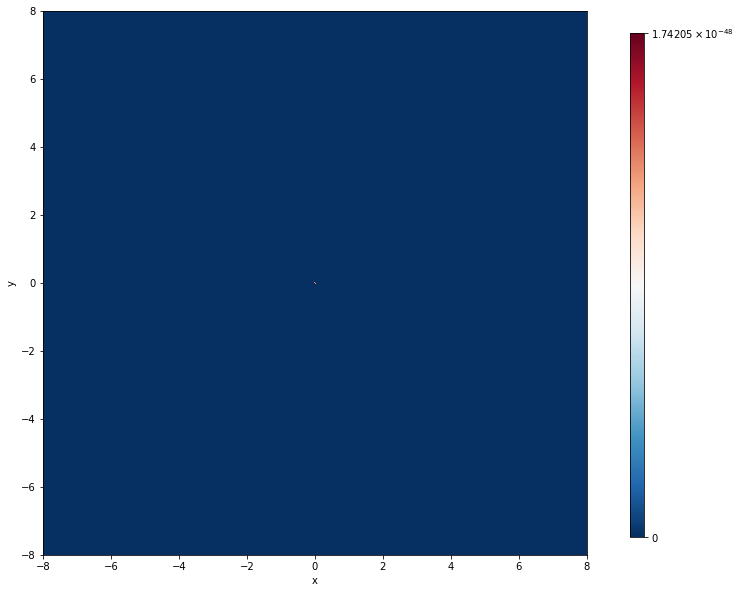

In [35]:
# Airy disk coupled into fiber
fiber_coupled = fiber_profile * I_intensity
output = np.sum(fiber_coupled) * dx * dy

fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax.pcolormesh(x, y, fiber_coupled, cmap='RdBu_r', 
                    norm=matplotlib.colors.SymLogNorm(linthresh=1e-5, 
                                                      vmin=fiber_coupled.min(), vmax=fiber_coupled.max()))
ax.set_xlabel('x')
ax.set_ylabel('y')
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()

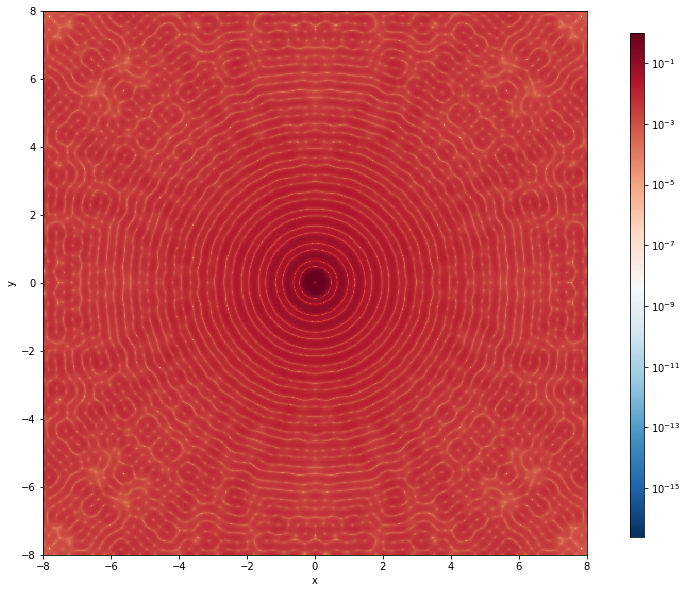

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'aspect':1})
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='gray', alpha = 1.)
ax0 = ax.pcolormesh(x, y, I_intensity, cmap='RdBu_r', 
                    norm=matplotlib.colors.LogNorm(vmin=I_intensity.min(), vmax=I_intensity.max()))
ax.set_xlabel('x')
ax.set_ylabel('y')
cax = fig.add_axes([0.95, 0.15, 0.02, 0.7]) #this locates the axis that is used for your colorbar. It is scaled 0 - 1. 
fig.colorbar(ax0, cax, orientation = 'vertical') #'ax0' tells it which plot to base the colors on
plt.show()